# Data & Env Initialization

In [1]:
import os, sys, gc

import zipfile
from os import path
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

zip_file = "Sky-dataset/Sky303.zip"
data_path = "Sky-dataset/Sky303/"

if not path.exists(data_path):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("Sky-dataset/")

input_indice_path = data_path + "input_indices_{}.npy"
input_data_path = data_path + "input_data_{}.npy"
target_path = data_path + "output_indices_{}.npy"

# Constants

In [2]:
N_CONFIGURATIONS = 4262 # number of configurations of the problem
IMG_SHAPE = (1355, 3384, 3)
H, W = 128, 256 # the window size

CAMERA = np.array([[2304.5479, 0,  1686.2379], # the camera matrix
                          [0, 2305.8757, -0.0151],
                          [0, 0, 1.]], dtype=np.float32)

# Data Viz & Utils

In [3]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)
torch.__version__

'1.3.1+cu92'

In [4]:
class Sky303Dataset(Dataset):
    """Car dataset."""

    def __init__(self):
        super(Sky303Dataset,self).__init__()

    def __len__(self):
        return N_CONFIGURATIONS

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        indice_np = np.load(input_indice_path.format(idx))
        input_np = np.load(input_data_path.format(idx))
        target_np = np.load(target_path.format(idx))
        
        input_bin_mask = np.zeros([H, W, 1], dtype='float16')
        input_bin_mask[indice_np[:,0],indice_np[:,1],:] = 1.
        
        input_2Drepr = np.zeros([H, W, 3], dtype='float16')
        input_2Drepr[indice_np[:,0],indice_np[:,1],:] = input_np
        
        target_2Drepr = np.zeros([H, W, 1], dtype='float16')
        target_2Drepr[target_np[:,0],target_np[:,1],:] = 1.
        
        input_bin_mask = np.rollaxis(input_bin_mask, 2, 0)
        input_bin_mask = torch.from_numpy(input_bin_mask).float()
        
        input_2Drepr = np.rollaxis(input_2Drepr, 2, 0)
        input_2Drepr = torch.from_numpy(input_2Drepr).float()
        
        target_2Drepr = np.rollaxis(target_2Drepr, 2, 0)
        target_2Drepr = torch.from_numpy(target_2Drepr).float()
        
        return [input_bin_mask, input_2Drepr, target_2Drepr]

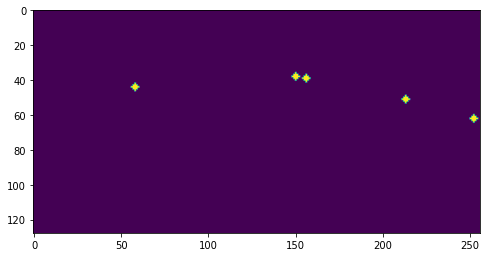

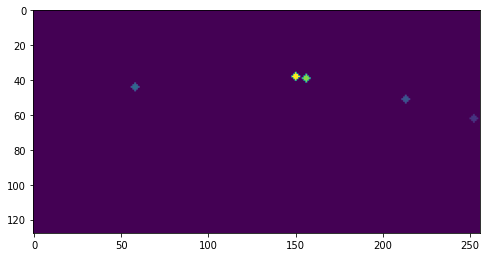

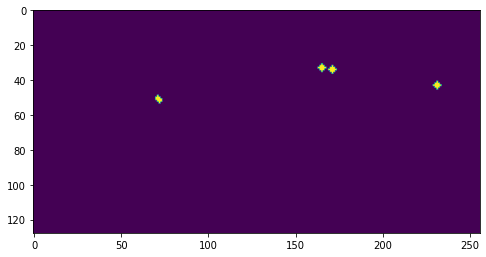

In [5]:
dataset = Sky303Dataset()
input_bin_mask, input_2Drepr, target_2Drepr = dataset[0]

plt.figure(figsize=(8,8))
plt.imshow((input_bin_mask.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(input_2Drepr.permute(1,2,0).numpy()[:,:,-1]/350.)
plt.show()

plt.figure(figsize=(8,8))
plt.imshow((target_2Drepr.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

# Model

In [6]:
import torch.nn as nn
import torch.optim as optim
from smap import *

# Gets the GPU if there is one, otherwise the cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
class Model(nn.Module):
    def __init__(self, camera_matrix, n=0):
        super(Model,self).__init__()
        self.n = n
        self.camera_matrix = nn.Parameter(torch.from_numpy(camera_matrix), requires_grad=False)
        self.camera_matrix_inv = nn.Parameter(torch.from_numpy(np.linalg.inv(camera_matrix)), requires_grad=False)
        
        self.phi = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1), requires_grad=True)
        self.gamma = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1), requires_grad=True)
        self.rho = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1), requires_grad=True)
        self.theta = nn.Parameter(torch.from_numpy(np.array([0.,-0.,0.])).float().reshape(1,3,1,1), requires_grad=True)
        self.smap_layer = SMap(IMG_SHAPE[0], IMG_SHAPE[1], camera_matrix, device, n)
        
        self.I00 = nn.Parameter(torch.from_numpy(np.array([[1.,.0,.0],[.0,0.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I01 = nn.Parameter(torch.from_numpy(np.array([[0.,1.,.0],[.0,0.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I10 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[1.,0.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I11 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[.0,1.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I22 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[.0,0.,.0],[.0,.0,1.]])).float().reshape(3,3), requires_grad=False)
        
        self.net = nn.Sequential(nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=True), 
                                 nn.ReLU(), 
                                 nn.Conv2d(16, 64, kernel_size=3, stride=1, padding=1, bias=True), 
                                 nn.ReLU(), 
                                 nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, bias=True))
        
        from tools.testing.vtest.vtest_types import NoneBot
        def get_activation_grad():
            def hook(module, grad_input, grad_output):
                print("grad_output[0].shape")
                print(grad_output[0].shape)
                
                print((grad_output[0]).min())
                print((grad_output[0]).max())
                grad_out = (grad_output[0])[0:1,0,:,:]
                print(grad_out)
                plt.figure(figsize=(8,8))
                plt.imshow((grad_out.permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
                plt.show()
            return hook

        self.bot = NoneBot()
        self.bot.register_backward_hook(get_activation_grad())
        
    def forward(self, r_x, r_mask, target_2Dr=None, zoom=0):
        from smap import utils
        mask = self.bot(torch.sigmoid(1e-2*self.net(r_mask)))
        
        x = 1.*(r_x[:,-1:,:,:])
        height, width = x.size(-2), x.size(-1)
        panels = list(np.where(np.ones([height, width])))
        panels[0] = panels[0] + .5
        panels[1] = panels[1] + .5
        
        x = utils.to_3d(x.reshape(-1,1,height,width), height, width, panels, (height, width), IMG_SHAPE, self.camera_matrix_inv, device)
        
        phi = torch.tanh(3e-2*self.phi)*np.pi
        gamma = torch.tanh(3e-2*self.gamma)*np.pi
        rho = torch.tanh(3e-2*self.rho)*np.pi
        theta = self.theta.detach()+torch.sqrt(1.+3e-2*self.theta.detach())*(self.theta-self.theta.detach())
        r = torch.cos(phi)*self.I00-torch.sin(phi)*self.I01+torch.sin(phi)*self.I10+torch.cos(phi)*self.I11+self.I22
        y = torch.cos(gamma)*self.I00-torch.sin(gamma)*self.I01+torch.sin(gamma)*self.I10+torch.cos(gamma)*self.I11+self.I22
        p = torch.cos(rho)*self.I00-torch.sin(rho)*self.I01+torch.sin(rho)*self.I10+torch.cos(rho)*self.I11+self.I22
        
        x_r = torch.einsum('bdef,cd->bcef',x,r)
        x_r = torch.cat([x_r[:,1:,:,:],x_r[:,:1,:,:]],dim=1)
        x_r = torch.einsum('bdef,cd->bcef',x_r,y)
        x_r = torch.cat([x_r[:,1:,:,:],x_r[:,:1,:,:]],dim=1)
        x_r = torch.einsum('bdef,cd->bcef',x_r,p)
        x_r = torch.cat([x_r[:,1:,:,:],x_r[:,:1,:,:]],dim=1)
        
        x_t = x_r+(mask>.5).float()*theta
        x_z = torch.where(torch.abs(x_t[:,-1:,:,:])>.5, 0.*(x_t[:,-1:,:,:]), 0.*(x_t[:,-1:,:,:])+(2.*((x_t[:,-1:,:,:])>0.).float()-1.)*.5)
        temp = torch.cat([torch.zeros_like(x_t[:,:-1,:,:]), x_z], dim=1)
        x_t = x_t+temp.detach()
        x_t = torch.where((x[:,-1:,:,:])>0.,x_t,x_t.detach())
        x_t = torch.where((mask>.5),x_t,temp)
        k_t = torch.max(torch.abs(x_t[:,:-1,:,:]),dim=1,keepdim=True).values
        k_d = torch.abs(x_t[:,-1:,:,:])
        k_t = torch.max(torch.abs(x_t[:,:-1,:,:]),dim=1,keepdim=True).values
        k_d = torch.where((k_d/(k_t+1.))>1., 3e-0*(k_d+1.)**(4)/((k_d+1.)**(5)+1.)*k_d, 3e-1/((k_d+1e7)**(2-1e-2)/(k_d+1e7)**(-1e-2))*(k_d**2))
        k_t = k_d.detach()/((x_t[:,-1:,:,:])+torch.exp(-1e7*(x_t[:,-1:,:,:]).detach()))
        
        weights = self.smap_layer(torch.cat([k_t*x_t, (mask)], dim=1), target_2Dr, zoom)
        
        return phi, gamma, rho, mask, weights

In [8]:
def create_model(camera_matrix, n):
    return Model(camera_matrix, n)

# Datasets

In [9]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, SequentialSampler, SubsetRandomSampler

In [10]:
train_idx, valid_idx= train_test_split(
    np.random.choice(np.arange(N_CONFIGURATIONS), size=512, replace=False), test_size=0.25, random_state=0, shuffle=True)

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SequentialSampler(valid_idx)

# Training

In [11]:
def l1_error(pred, target):
    from smap import specials
    shapes = target.size()
    m_batch_size, height, width = shapes[0], shapes[-2], shapes[-1]
    
    pred_m = (torch.max((pred>specials.OFF_THRESH).reshape(m_batch_size, -1, height*width),dim=1,keepdim=True).values).float()
    abs_pred = torch.abs(pred)
    pred = ((1.-2e-3)*abs_pred.detach()+1e-3+(2.*((pred)>0.).float()-1.)*(pred-pred.detach())).reshape(m_batch_size, -1, height*width)
    target_m = target.reshape(m_batch_size, 1, -1)
    
    loss = torch.abs(pred-target_m)
    loss_m = torch.abs(pred_m-target_m)
    
    denom = loss.reshape(m_batch_size, -1).sum(dim=1)
    denom = torch.where(denom>1e1,denom,0.*denom+1e-1)
    loss = loss.reshape(m_batch_size, -1).sum(dim=1)/denom.detach()
    loss_m = loss_m.reshape(m_batch_size, -1).sum(dim=1)
    
    loss = torch.mean(loss_m.detach()+1e5*(loss-loss.detach()))
    return loss

def train_loop_fn(loader, zoom, epoch, history=None):
    model.train()
    for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
        m_batchsize, height, width = r_mask_batch.size(0), r_mask_batch.size(-2), r_mask_batch.size(-1)
        if m_batchsize != batch_size:
            break
        else:
            r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

        optimizer.zero_grad()
        
        r, p, y, r_mask, weights = model(input_2Dr_batch, r_mask_batch, target_2Dr_batch, zoom)
        
        target_2Dr = target_2Dr_batch.reshape(m_batchsize,1,H//(2**zoom),(2**zoom),W//(2**zoom),(2**zoom)).permute(0,3,5,1,2,4).reshape(m_batchsize,(2**(zoom+zoom)),1,H//(2**zoom),W//(2**zoom))
        target_2Dr, _ = torch.max(target_2Dr,dim=1,keepdim=False)
        
        r_mask = r_mask_batch.reshape(m_batchsize,1,H//(2**zoom),(2**zoom),W//(2**zoom),(2**zoom)).permute(0,3,5,1,2,4).reshape(m_batchsize,(2**(zoom+zoom)),1,H//(2**zoom),W//(2**zoom))
        r_mask, _ = torch.max(r_mask,dim=1,keepdim=False)


        loss = l1_error(weights, target_2Dr)
        
        loss.backward()
        optimizer.step()
        
        print(weights.min())
        print(weights.max())
        out_batch = utils.recover_size(weights, n, zoom)
        out_batch = torch.max((out_batch.reshape(m_batchsize,1,-1,out_batch.size(-2), out_batch.size(-1))>specials.OFF_THRESH).float(),dim=2,keepdim=False).values.reshape(m_batchsize,1,out_batch.size(-2), out_batch.size(-1))
        print("out_batch")
        print(out_batch.min())
        print(out_batch.max())
        
        p = torch.tanh(3e-2*model.phi)*np.pi
        y = torch.tanh(3e-2*model.gamma)*np.pi
        r = torch.tanh(3e-2*model.rho)*np.pi
        print('theta_x: %.4f' % ((model.theta[0,0,0,0]).detach().cpu().numpy()))
        print('theta_y: %.4f' % ((model.theta[0,1,0,0]).detach().cpu().numpy()))
        print('theta_z: %.4f' % ((model.theta[0,2,0,0]).detach().cpu().numpy()))
        print('phi: %.4f' % ((r[0,0]).detach().cpu().numpy()))
        print('gamma: %.4f' % ((p[0,0]).detach().cpu().numpy()))
        print('rho: %.4f' % ((y[0,0]).detach().cpu().numpy()))

        loss_np = loss.detach().cpu().numpy()

        history.loc[(zoom, epoch, batch_idx), 'theta_x'] = (model.theta[0,0,0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'theta_y'] = (model.theta[0,1,0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'theta_z'] = (model.theta[0,2,0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'phi'] = (r[0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'gamma'] = (p[0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'rho'] = (y[0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'loss'] = loss_np
        
    print('Train Epoch: ({}, {}) \tLR: {:.6f}\tLoss: {:.6f}'.format(
            zoom, epoch,
            optimizer.state_dict()['param_groups'][0]['lr'],
            history['loss'].iloc[(-len(train_loader)+1):].mean()))
    
def evaluate_model(loader, key, history=None):
    model.eval()
    loss_np = 0.
    count = 0.

    with torch.no_grad():
        for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
            m_batchsize = r_mask_batch.size(0)
            if m_batchsize != batch_size:
                break
            r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

            optimizer.zero_grad()

            r, p, y, r_mask, weights = model(input_2Dr_batch, r_mask_batch)
            
            print(weights.min())
            print(weights.max())
            out_batch = utils.recover_size(weights, n)
            out_batch = torch.max((out_batch.reshape(m_batchsize,1,-1,out_batch.size(-2), out_batch.size(-1))>specials.OFF_THRESH).float(),dim=2,keepdim=False).values.reshape(m_batchsize,1,out_batch.size(-2), out_batch.size(-1))
            print("out_batch")
            print(out_batch.min())
            print(out_batch.max())
            plt.figure(figsize=(8,8))
            plt.imshow(((out_batch>specials.OFF_THRESH)[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
            plt.show()
            
            l1 = l1_error(weights, target_2Dr_batch)
            loss_np += l1.detach().cpu().numpy()
            count = count+1.
    loss_np /= count
    history.loc[key, 'theta_x'] = (model.theta[0,0,0,0]).detach().cpu().numpy()
    history.loc[key, 'theta_y'] = (model.theta[0,1,0,0]).detach().cpu().numpy()
    history.loc[key, 'theta_z'] = (model.theta[0,2,0,0]).detach().cpu().numpy()
    history.loc[key, 'phi'] = (r[0,0]).detach().cpu().numpy()
    history.loc[key, 'gamma'] = (p[0,0]).detach().cpu().numpy()
    history.loc[key, 'rho'] = (y[0,0]).detach().cpu().numpy()
    history.loc[key, 'dev_loss'] = loss_np
    print("n_epochs: {} - lr: {}".format(*key))
    print('theta_x: {:.4f}'.format((model.theta[0,0,0,0]).detach().cpu().numpy()))
    print('theta_y: {:.4f}'.format((model.theta[0,1,0,0]).detach().cpu().numpy()))
    print('theta_z: {:.4f}'.format((model.theta[0,2,0,0]).detach().cpu().numpy()))
    print('phi: {:.4f}'.format((r[0,0]).detach().cpu().numpy()))
    print('gamma: {:.4f}'.format((p[0,0]).detach().cpu().numpy()))
    print('rho: {:.4f}'.format((y[0,0]).detach().cpu().numpy()))
    print('Dev loss: {:.4f}'.format(loss_np))

Wall time: 0 ns


  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0091, device='cuda:0')
tensor(0.0091, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  2.6453e-01,  2.6453e-01,  2.6453e-01,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.2770e-01,  1.2770e-01,  1.2770e-01,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  2.6453e-01, -2.6453e-01, -2.0670e+01,  0.0000e+00,
           0.0000e+00,  9.1217e-02,  9.1217e-02,  9.1217e-02,  0.0000e+00,
           0.0000e+00],
         [ 1.2770e-01, -1.2770e-01,  1.2770e-01,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  2.6453e-01,  2.6453e-01,  2.6453e-01,  0.0000e+00,

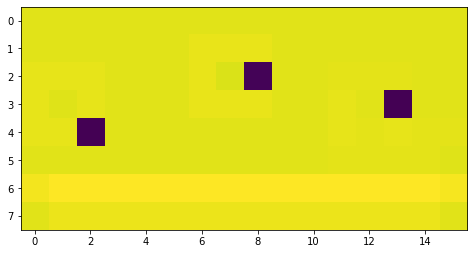

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0912, device='cuda:0')
tensor(0.1460, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0899, 0.0899, 0.0899,  ..., 0.0899, 0.0899, 0.0000],
         [0.0899, 0.0899, 0.0899,  ..., 0.0899, 0.0899, 0.0899]]],
       device='cuda:0')


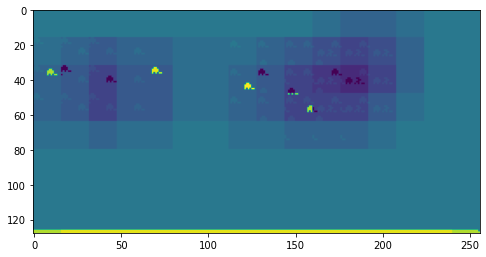

  4%|███▍                                                                               | 1/24 [00:02<00:56,  2.47s/it]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0021
theta_y: -0.0004
theta_z: 0.0006
phi: 0.0004
gamma: -0.0003
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[  0.2734,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.4101,   0.1367,   0.0000,   0.1196,   0.4101,   0.3076,  -0.0854,
            0.0854,  -0.2051,   0.1196,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.4101,   0.1367,   0.0000,   0.1196,   0.3931, -17.3543, -18.0123,
          -19.1743, -18.6360, -19.4734,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.4101,   0.1367,   0.0000,   0.1196,   0.4

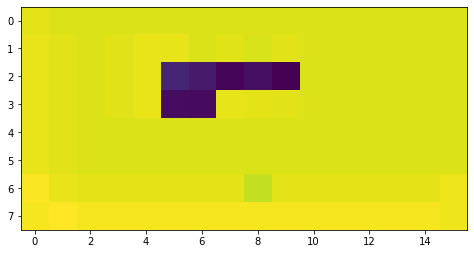

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.1435, device='cuda:0')
tensor([[[0.0342, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0342, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0342, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.1025, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.1025, 0.1025, 0.1025,  ..., 0.1025, 0.1025, 0.1025],
         [0.1025, 0.1025, 0.1025,  ..., 0.1025, 0.1025, 0.1025]]],
       device='cuda:0')


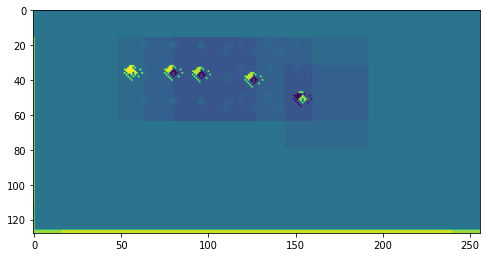

  8%|██████▉                                                                            | 2/24 [00:03<00:44,  2.01s/it]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0063
theta_y: 0.0012
theta_z: 0.0011
phi: 0.0013
gamma: -0.0012
rho: -0.0007
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0068, device='cuda:0')
tensor(0.0068, device='cuda:0')
tensor([[[ 6.9494e+00,  3.4713e+00,  3.4237e+00,  3.4305e+00,  3.5868e+00,
           3.4305e+00,  3.4305e+00,  3.4781e+00, -1.0393e+01,  3.4781e+00,
           3.4781e+00,  3.4781e+00,  3.4781e+00,  3.4781e+00,  3.4781e+00,
           6.9562e+00],
         [ 1.0319e+01,  1.1969e+01,  1.1671e+01,  1.2037e+01,  1.2262e+01,
           1.0298e+01,  8.9805e+00, -2.1059e-01, -3.3966e-02,  0.0000e+00,
          -1.2228e-01,  9.0349e+00, -9.5104e-02,  0.0000e+00, -1.6983e-01,
           8.6069e+00],
         [ 8.4574e+00, -1.9700e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           6.5214e+00,  0.0000e+00,  0.0000e+00,  0.0000

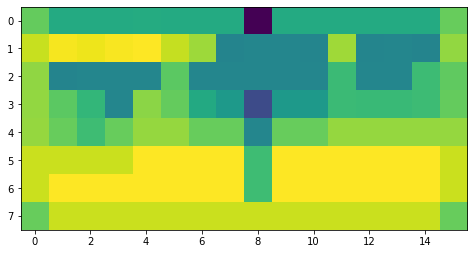

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0804, device='cuda:0')
tensor(0.1367, device='cuda:0')
tensor([[[0.0926, 0.0926, 0.0926,  ..., 0.0926, 0.0926, 0.0926],
         [0.0926, 0.0926, 0.0926,  ..., 0.0926, 0.0926, 0.0926],
         [0.0926, 0.0926, 0.0926,  ..., 0.0926, 0.0926, 0.0926],
         ...,
         [0.0926, 0.0926, 0.0926,  ..., 0.0926, 0.0926, 0.0926],
         [0.0926, 0.0926, 0.0926,  ..., 0.0926, 0.0926, 0.0926],
         [0.0926, 0.0926, 0.0926,  ..., 0.0926, 0.0926, 0.0926]]],
       device='cuda:0')


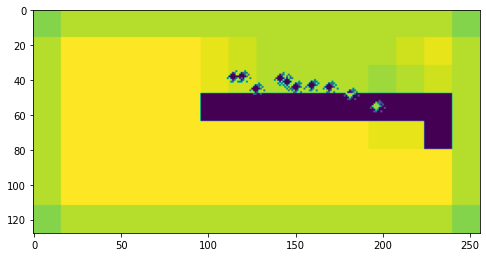

 12%|██████████▍                                                                        | 3/24 [00:04<00:36,  1.74s/it]

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -18.5994, -18.5994,   0.0000,   0.0000,   0.0000,   0.0000,
          -18.5994, -18.5994,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,

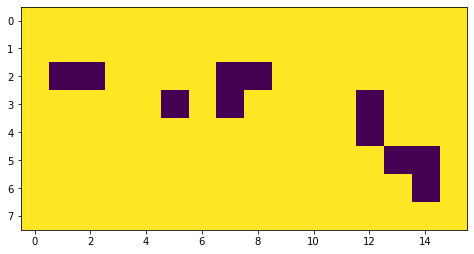

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0477, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


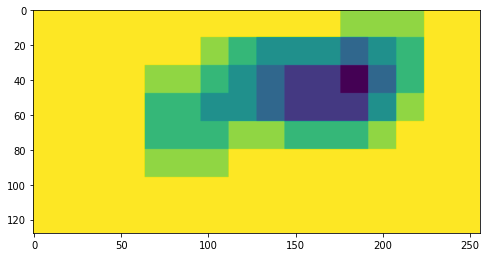

 17%|█████████████▊                                                                     | 4/24 [00:05<00:30,  1.53s/it]

tensor(-0.2497, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -18.2340,   0.0000, -18.2340,   0.0000,   0.0000,   0.0000,
            0.0000, -18.2340, -18.2340, -18.2340, -18.2340,   0.0000,   0.0000,
            0.0000, -18.2340],
         [  0.0000, -18.2340, -18.2340,   0.0000,   0.0000,   0

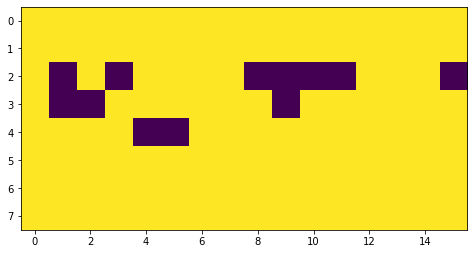

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0541, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ..., -0.0141, -0.0141, -0.0141],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0141, -0.0141, -0.0141],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0141, -0.0141, -0.0141],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
       device='cuda:0')


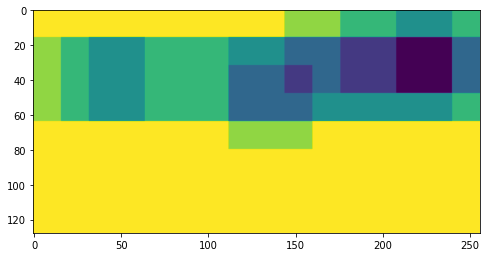

 21%|█████████████████▎                                                                 | 5/24 [00:06<00:25,  1.35s/it]

tensor(-0.2497, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -18.6856],
         [  0.0000,   0.0000,   0.0000,   0.0000, -18.6856, -18.6856,   0.0000,
            0.0000,   0.0000, -18.6856, -18.6856, -18.6856, -18.6856, -18.6856,
          -18.6856, -18.6856],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0

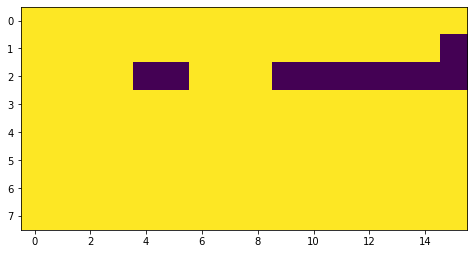

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0491, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


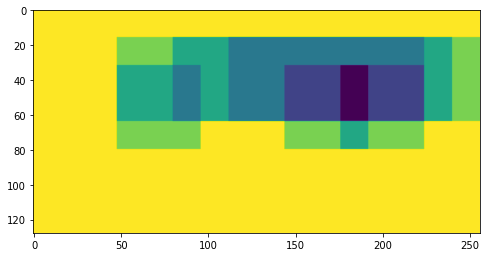

 25%|████████████████████▊                                                              | 6/24 [00:07<00:21,  1.21s/it]

tensor(-0.2497, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -18.5888,
          -18.5888, -18.5888, -18.5888, -18.5888, -18.5888,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -18.5888, -18.5888,   0

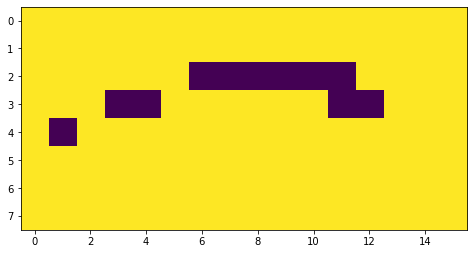

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0499, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


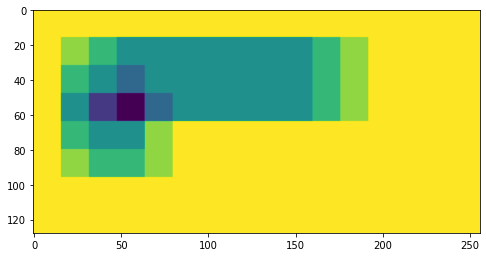

 29%|████████████████████████▏                                                          | 7/24 [00:08<00:19,  1.14s/it]

tensor(-0.2498, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0082, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -18.8659, -18.8659,   0.0000,
            0.0000, -18.8659, -18.8659, -18.8659, -18.8659, -18.8659, -18.8659,
          -18.8659,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -18.8659,   0

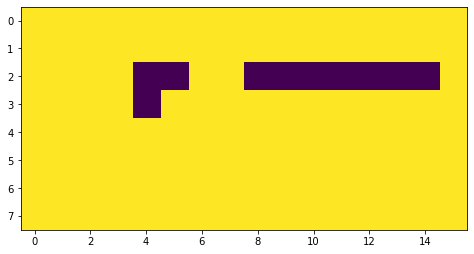

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0518, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


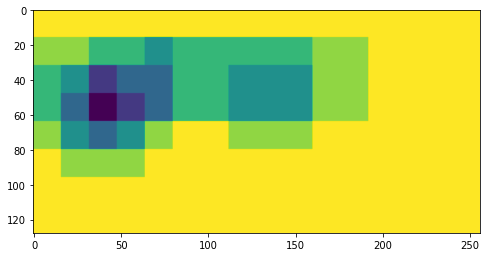

 33%|███████████████████████████▋                                                       | 8/24 [00:09<00:17,  1.09s/it]

tensor(-0.2498, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0084, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -19.4500, -19.4500,
          -19.4500, -19.4500, -19.4500, -19.4500,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000, -19.4500,   0.0000, -19.4500,   0

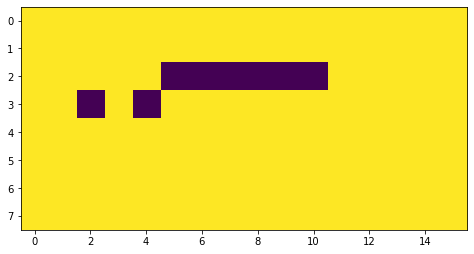

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0526, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


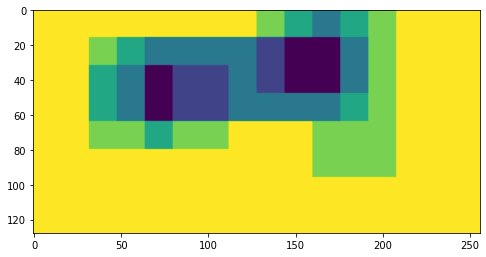

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:15,  1.04s/it]

tensor(-0.2498, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -19.7543, -19.7543,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -19.7543,   0.0000,   0.0000, -19.7543,
            0.0000, -19.7543, -19.7543,   0.0000, -19.7543,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0

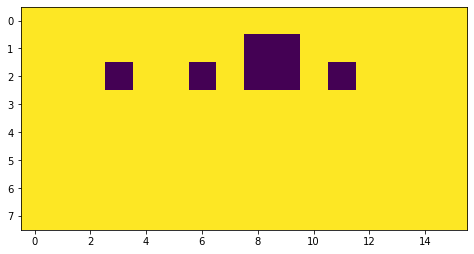

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0489, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


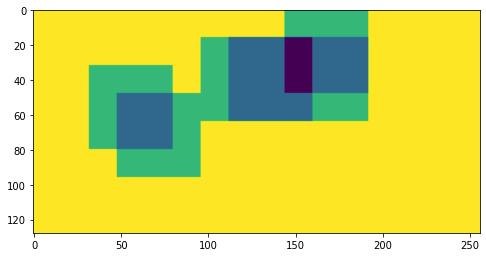

 42%|██████████████████████████████████▏                                               | 10/24 [00:11<00:14,  1.02s/it]

tensor(-0.2498, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0084, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -19.4447,   0.0000, -19.4447,
          -19.4447, -19.4447, -19.4447,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -19.4447,   0

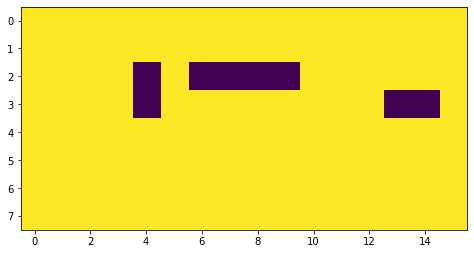

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0444, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


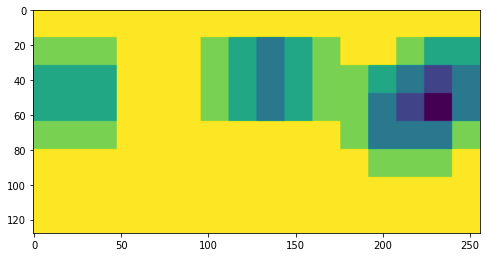

 46%|█████████████████████████████████████▌                                            | 11/24 [00:12<00:13,  1.03s/it]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -20.0664, -20.0664, -20.0664, -20.0664, -20.0664,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0

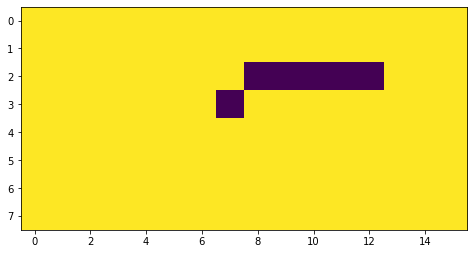

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0548, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083]]],
       device='cuda:0')


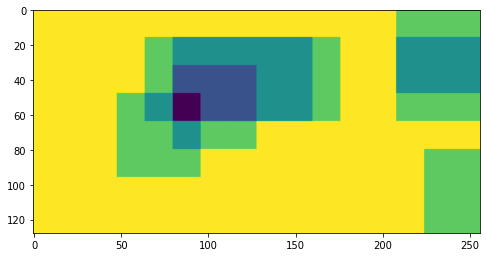

 50%|█████████████████████████████████████████                                         | 12/24 [00:13<00:12,  1.04s/it]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -19.1430,
          -19.1430, -19.1430, -19.1430, -19.1430, -19.1430, -19.1430,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0

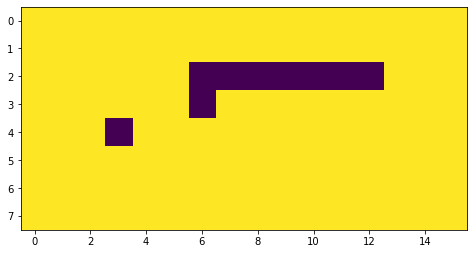

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0609, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


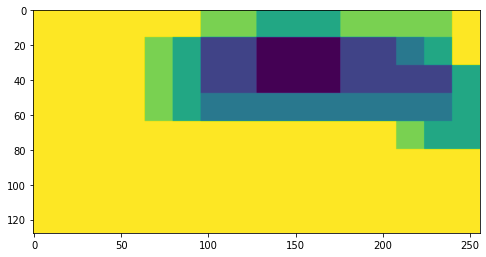

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:14<00:11,  1.00s/it]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -18.6655, -18.6655,   0.0000,   0.0000,   0.0000, -18.6655,
          -18.6655, -18.6655,   0.0000, -18.6655,   0.0000,   0.0000,   0.0000,
            0.0000, -18.6655],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0

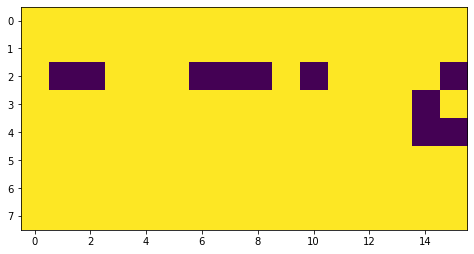

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0556, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


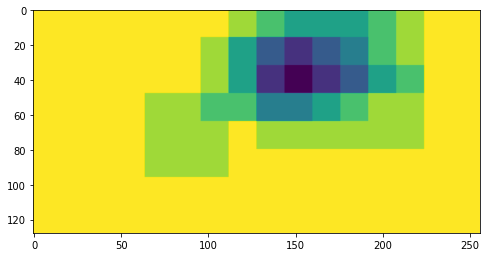

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:15<00:09,  1.03it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -19.7424, -19.7424, -19.7424,   0.0000,
          -19.7424, -19.7424, -19.7424,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0

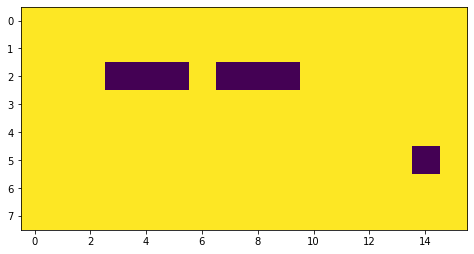

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0484, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


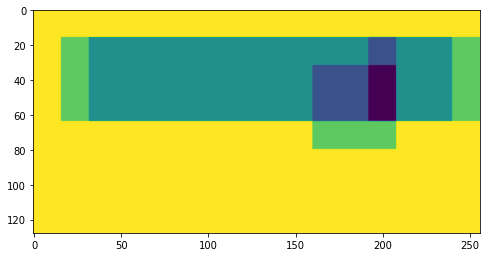

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:16<00:08,  1.03it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0070, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -16.1011, -16.1011, -16.1011, -16.1011, -16.1011, -16.1011,
          -16.1011, -16.1011, -16.1011, -16.1011,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -16.1011, -16.1011, -16.1011,   0.0000,   0

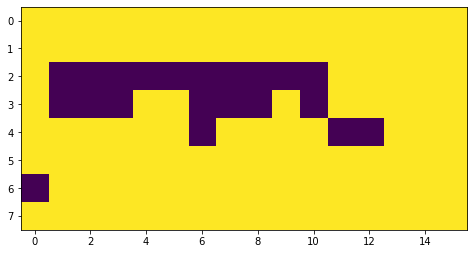

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0489, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


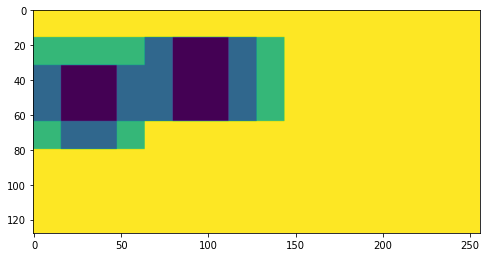

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:17<00:07,  1.04it/s]

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0090, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -20.7183,
            0.0000, -20.7183, -20.7183,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -20.7183,   0.0000,   0

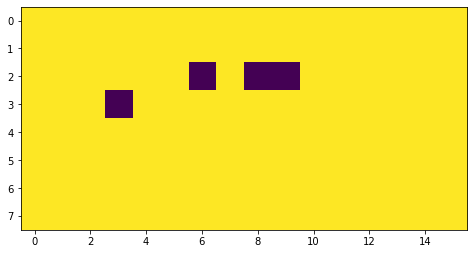

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0552, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


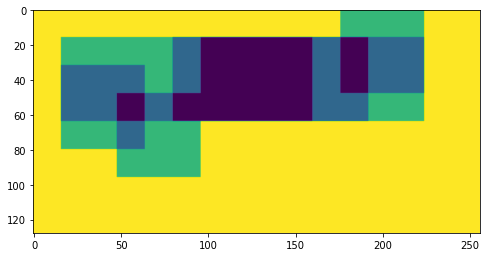

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:17<00:06,  1.06it/s]

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0088, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -20.3792, -20.3792, -20.3792,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -20.3792, -20

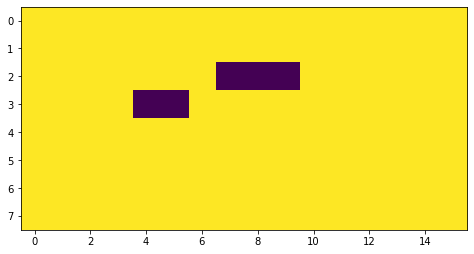

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0870, device='cuda:0')
tensor(0.1218, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


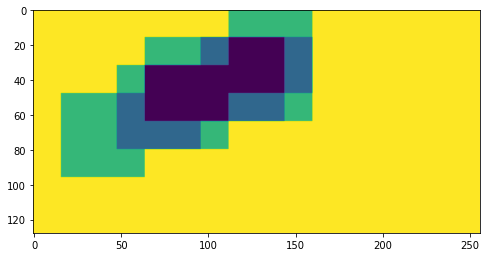

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:18<00:05,  1.08it/s]

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5000, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0094
theta_y: -0.0003
theta_z: 0.0018
phi: 0.0021
gamma: -0.0019
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0073, device='cuda:0')
tensor(0.0073, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.9070e-02,  2.9070e-02,  3.6337e-02,  2.1802e-02,  7.2674e-03,
          -7.2674e-03,  6.5407e-02,  3.6337e-02, -7.2674e-02, -1.6468e+01,
          -1.4535e-02,  2.1802e-02,  3.6337e-02,  7.2674e-03,  0.0000e+00,
           0.0000e+00],
         [ 2.9070e-02, -1.6541e+01, -1.6577e+01, -1.6519e+01, -1.6606e+01,
          -1.6606e+01, -1.6526e+01, -1.6497e+01, -1.644

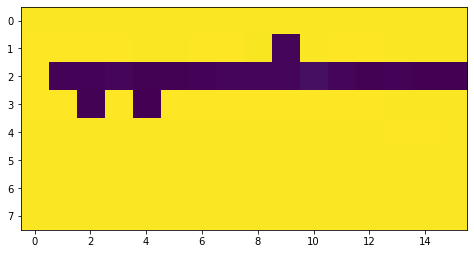

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.1438, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


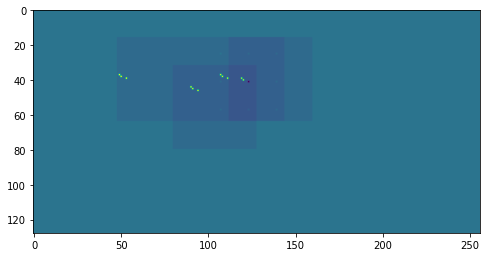

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:19<00:04,  1.09it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0097
theta_y: -0.0004
theta_z: 0.0019
phi: 0.0022
gamma: -0.0020
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 1.7386e-02,  1.7386e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  8.6928e-03,
           8.6928e-03],
         [ 1.7386e-01,  1.7386e-01,  1.7386e-02,  2.6948e-01,  2.7817e-01,
           8.6928e-03,  2.6078e-01,  2.2601e-01, -2.5209e-01,  8.6928e-03,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  8.6928e-03,
           8.6928e-03],
         [ 1.5647e-01, -1.7386e-02, -1.9872e+01,  2.6948e-01,  3.4771e-02,
          -1.9098e+01, -1.9211e+01, -1.6334e+01, -1.944

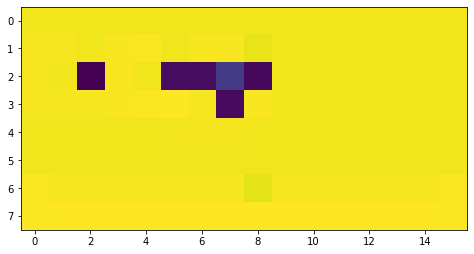

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0898, device='cuda:0')
tensor(0.1527, device='cuda:0')
tensor([[[0.0311, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0311],
         [0.0311, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0934, 0.0000, 0.0000,  ..., 0.0000, 0.0934, 0.0934],
         [0.0934, 0.0934, 0.0934,  ..., 0.0934, 0.0934, 0.0934]]],
       device='cuda:0')


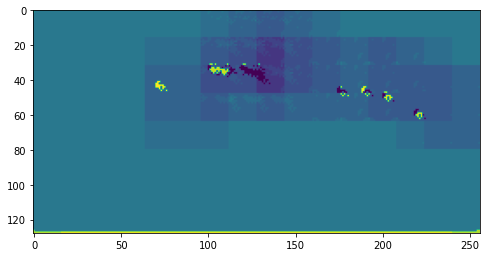

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:20<00:03,  1.10it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0145
theta_y: -0.0010
theta_z: 0.0020
phi: 0.0031
gamma: -0.0026
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[  0.5466,   0.4078,   0.4165,   0.4165,   0.4165,   0.4165,   0.4165,
            0.4165,   0.4165,   0.4165,   0.4165,   0.4165,   0.4165,   0.4165,
            0.4165,   0.5553],
         [  0.6854,   0.7115,   0.6334,   0.4078,   0.4859,   0.8242,   0.9023,
            0.5293,  -0.2343,   0.8242,   0.6420,   0.4425,   0.4165,   0.4165,
            0.5553,   0.6941],
         [  0.4165,   0.3644,   0.2603,   0.1041,   0.0868,   0.4078, -17.3092,
          -17.8905, -18.0988, -18.4719, -19.5824,   0.0260,   0.0000,   0.0000,
            0.1388,   0.4165],
         [  0.4165,   0.3644,   0.2950, -19.4436,   0.1

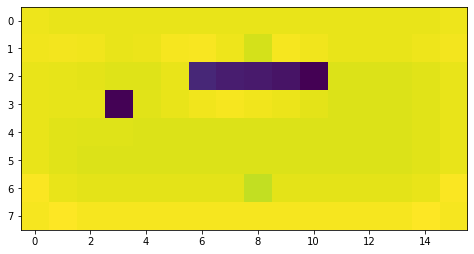

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0896, device='cuda:0')
tensor(0.1524, device='cuda:0')
tensor([[[0.0326, 0.0326, 0.0326,  ..., 0.0326, 0.0326, 0.0326],
         [0.0326, 0.0000, 0.0000,  ..., 0.0000, 0.0326, 0.0326],
         [0.0326, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0326],
         ...,
         [0.0978, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0978],
         [0.0978, 0.0978, 0.0978,  ..., 0.0978, 0.0978, 0.0978],
         [0.0978, 0.0978, 0.0978,  ..., 0.0978, 0.0978, 0.0978]]],
       device='cuda:0')


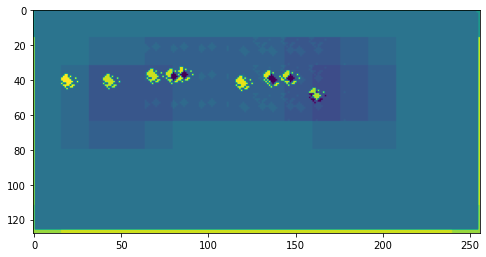

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:21<00:02,  1.10it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0189
theta_y: 0.0018
theta_z: 0.0022
phi: 0.0042
gamma: -0.0037
rho: -0.0019
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0076, device='cuda:0')
tensor(0.0076, device='cuda:0')
tensor([[[ 7.7552e+00,  3.8776e+00,  3.8776e+00,  3.8776e+00,  3.8776e+00,
           3.8776e+00,  3.8776e+00,  3.8776e+00, -1.1633e+01,  3.8776e+00,
           3.8776e+00,  3.8776e+00,  3.8776e+00,  3.8776e+00,  3.8776e+00,
           7.7552e+00],
         [ 1.1633e+01,  1.3572e+01,  1.3572e+01,  1.3572e+01,  1.3572e+01,
           1.3549e+01,  1.3201e+01,  1.3095e+01,  7.0812e+00,  1.3526e+01,
          -1.8934e-01,  1.1141e+01,  1.1633e+01,  1.3572e+01,  1.3572e+01,
           1.1633e+01],
         [ 1.1633e+01,  1.3572e+01,  1.3572e+01,  1.3572e+01,  1.3572e+01,
           1.3473e+01,  1.1186e+01,  8.9291e+00,  0.0000

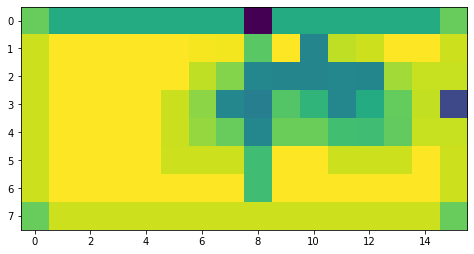

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0789, device='cuda:0')
tensor(0.1342, device='cuda:0')
tensor([[[0.0895, 0.0895, 0.0895,  ..., 0.0895, 0.0895, 0.0895],
         [0.0895, 0.0895, 0.0895,  ..., 0.0895, 0.0895, 0.0895],
         [0.0895, 0.0895, 0.0895,  ..., 0.0895, 0.0895, 0.0895],
         ...,
         [0.0895, 0.0895, 0.0895,  ..., 0.0895, 0.0895, 0.0895],
         [0.0895, 0.0895, 0.0895,  ..., 0.0895, 0.0895, 0.0895],
         [0.0895, 0.0895, 0.0895,  ..., 0.0895, 0.0895, 0.0895]]],
       device='cuda:0')


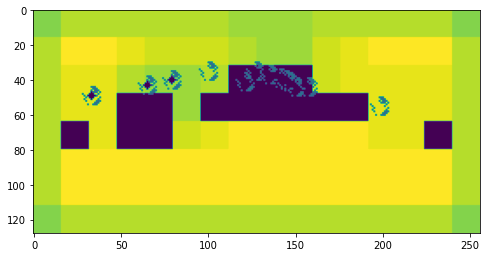

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:22<00:01,  1.08it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000, -16.9853,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -16.9853, -16.9853,
          -16.9853,   0.0000, -16.9853, -16.9853, -16.9853, -16.9853, -16.9853,
          -16.9853, -16.9853],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, 

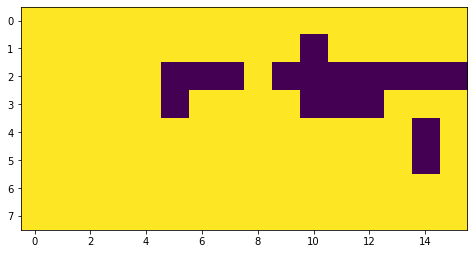

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0557, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


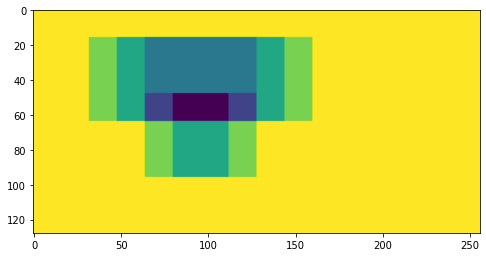

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:23<00:00,  1.09it/s]

tensor(-0.2498, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -16.9837, -16.9837,   0.0000,   0.0000,   0.0000, -16.9837,
          -16.9837,   0.0000],
         [  0.0000, -16.9837,   0.0000,   0.0000, -16.9837, -16.9837,   0.0000,
            0.0000, -16.9837, -16.9837, -16.9837, -16.9837, -16.9837, -16.9837,
          -16.9837, -16.9837],
         [  0.0000,   0.0000,   0.0000, -16.9837,   0.0000, -16.

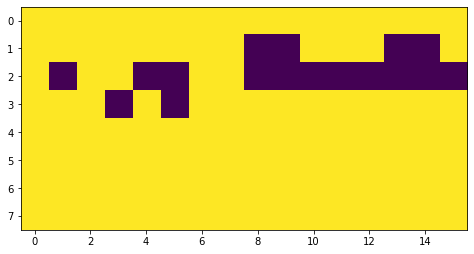

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0477, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ..., -0.0071, -0.0071, -0.0071],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0071, -0.0071, -0.0071],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0071, -0.0071, -0.0071],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
       device='cuda:0')


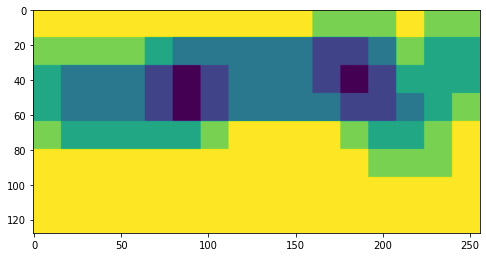

  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

tensor(-0.2498, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
Train Epoch: (4, 0) 	LR: 0.001000	Loss: 21.070652
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -19.7537,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -19.7537, -19.7537, -19.7537,
          -19.7537, -19.7537,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.

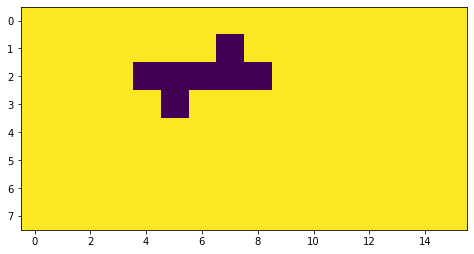

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0474, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


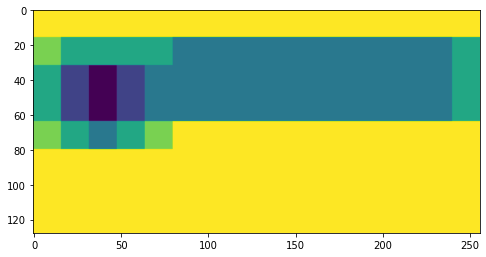

  4%|███▍                                                                               | 1/24 [00:00<00:20,  1.12it/s]

tensor(-0.2498, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0090, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000, -20.7337,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -20.7337,   0.0000,
            0.0000,   0.0000, -20.7337,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -20.7337,   0.0000,   0.

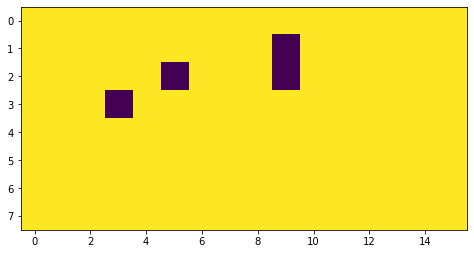

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0591, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0068, -0.0068, -0.0068],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0068, -0.0068, -0.0068],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0068, -0.0068, -0.0068]]],
       device='cuda:0')


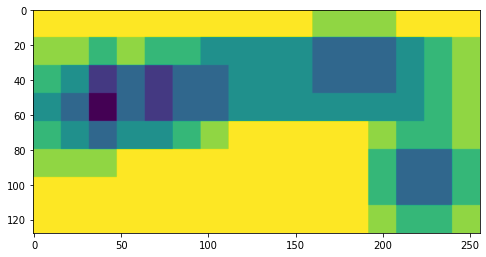

  8%|██████▉                                                                            | 2/24 [00:01<00:20,  1.10it/s]

tensor(-0.2498, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0069, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -15.9006,   0.0000,
            0.0000, -15.9006, -15.9006, -15.9006, -15.9006,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -15.9006, -15.9006, -15.9006, -15.9006,
          -15.9006, -15.9006, -15.9006, -15.9006, -15.9006,   0.0000, -15.9006,
          -15.9006, -15.9006],
         [  0.0000, -15.9006,   0.0000,   0.0000,   0.0000, -15.

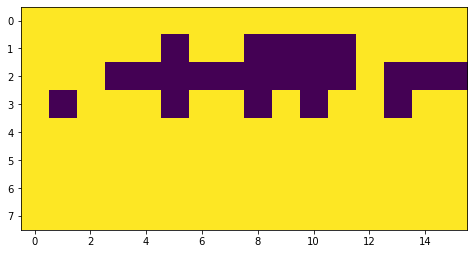

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0552, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


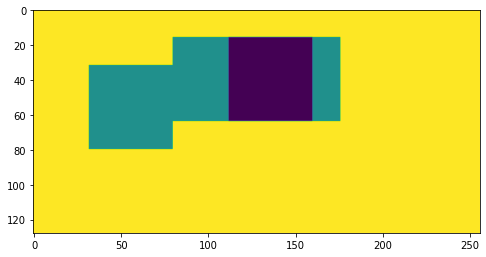

 12%|██████████▍                                                                        | 3/24 [00:02<00:19,  1.07it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000, -19.7476, -19.7476,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -19.7476, -19.7476, -19.7476,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.

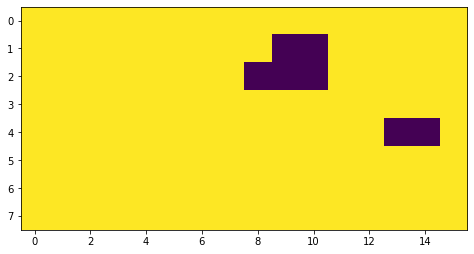

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0442, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0081, -0.0081, -0.0081],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0081, -0.0081, -0.0081],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0081, -0.0081, -0.0081]]],
       device='cuda:0')


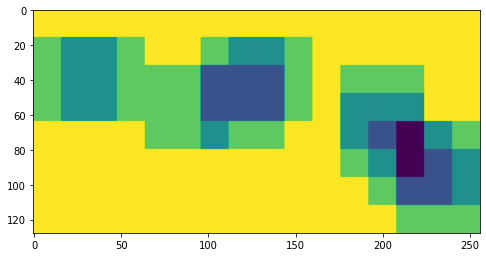

 17%|█████████████▊                                                                     | 4/24 [00:03<00:18,  1.08it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0088, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000, -20.3894,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000, -20.3894, -20.3894,   0.0000,   0.0000,   0.0000,
          -20.3894,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.

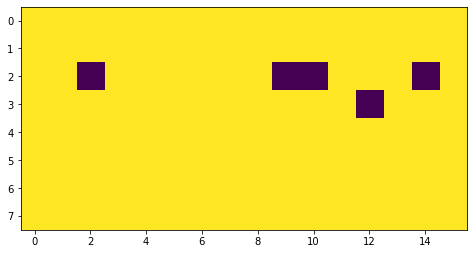

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0484, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


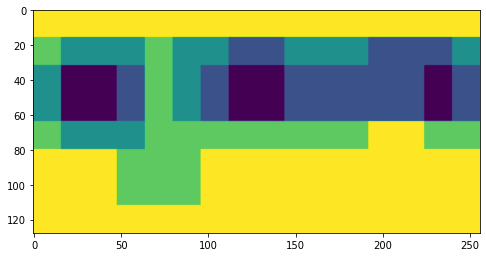

 21%|█████████████████▎                                                                 | 5/24 [00:04<00:17,  1.10it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0073, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000, -16.8242, -16.8242, -16.8242, -16.8242, -16.8242,
          -16.8242, -16.8242, -16.8242, -16.8242,   0.0000, -16.8242, -16.8242,
            0.0000,   0.0000],
         [  0.0000,   0.0000, -16.8242, -16.8242, -16.8242, -16.

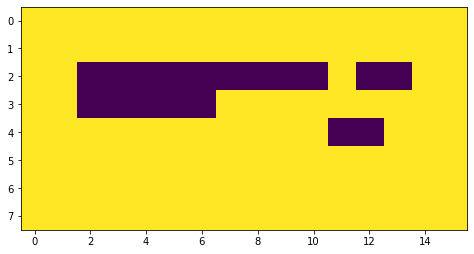

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0465, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


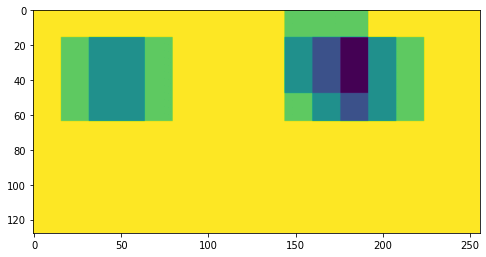

 25%|████████████████████▊                                                              | 6/24 [00:05<00:16,  1.12it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0075, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -17.3683, -17.3683,
          -17.3683, -17.3683,   0.0000,   0.0000,   0.0000,   0.0000, -17.3683,
          -17.3683, -17.3683],
         [  0.0000, -17.3683, -17.3683, -17.3683, -17.3683, -17.

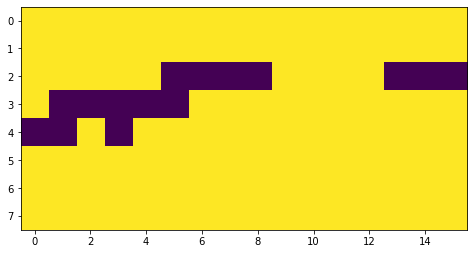

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0540, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


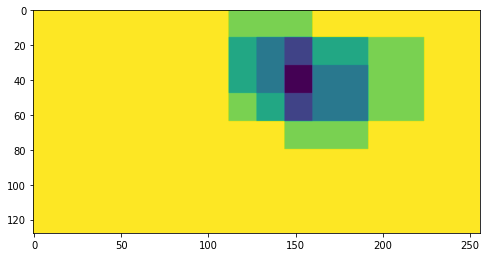

 29%|████████████████████████▏                                                          | 7/24 [00:06<00:15,  1.11it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -19.7409, -19.7409,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -19.7409,   0.0000,   0.0000, -19.7409,
            0.0000, -19.7409, -19.7409,   0.0000, -19.7409,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.

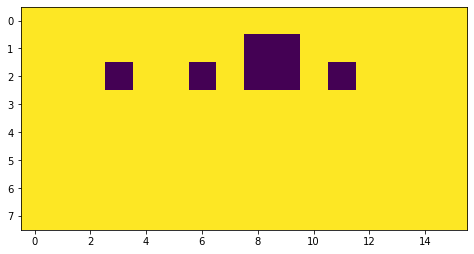

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0477, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


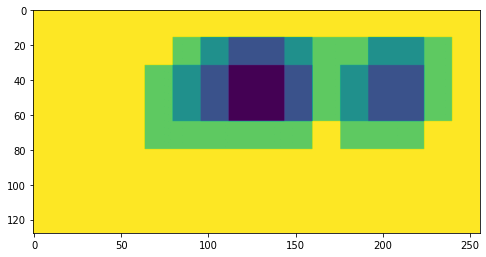

 33%|███████████████████████████▋                                                       | 8/24 [00:07<00:14,  1.07it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0078, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000, -18.0332, -18.0332,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -18.0332, -18.0332, -18.0332, -18.0332,
            0.0000, -18.0332, -18.0332, -18.0332, -18.0332,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -18.0332,   0.0000,   0.

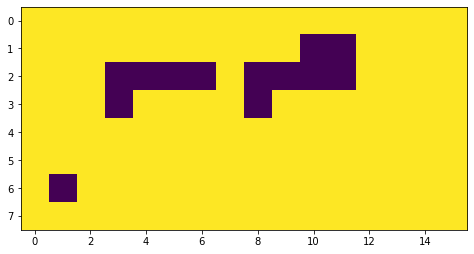

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0525, device='cuda:0')
tensor(0.1069, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


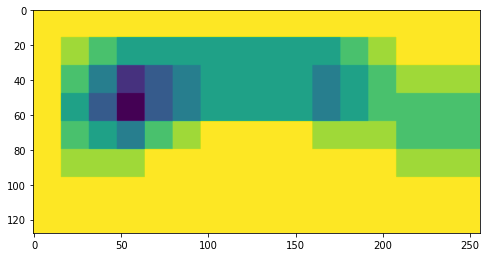

 38%|███████████████████████████████▏                                                   | 9/24 [00:08<00:13,  1.08it/s]

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5000, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -18.6594],
         [  0.0000,   0.0000,   0.0000,   0.0000, -18.6594, -18.6594,   0.0000,
            0.0000,   0.0000, -18.6594, -18.6594, -18.6594, -18.6594, -18.6594,
          -18.6594, -18.6594],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, 

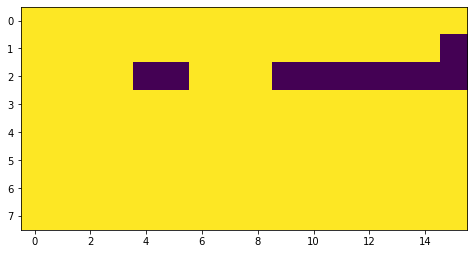

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0556, device='cuda:0')
tensor(0.1181, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


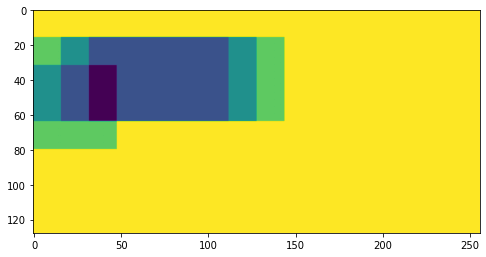

 42%|██████████████████████████████████▏                                               | 10/24 [00:09<00:12,  1.09it/s]

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5000, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0084, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -19.4305,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -19.4305, -19.4305, -19.4305, -19.4305,   0.0000, -19.4305,
          -19.4305,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, 

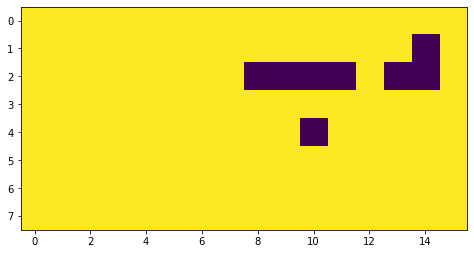

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0498, device='cuda:0')
tensor(0.1238, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


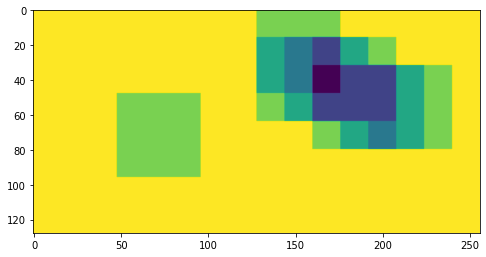

 46%|█████████████████████████████████████▌                                            | 11/24 [00:10<00:11,  1.10it/s]

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5000, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0078, device='cuda:0')
tensor(0.0078, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  7.8258e-03,  7.8258e-03,  0.0000e+00,  2.3477e-02,
           7.8258e-03, -1.5652e-02,  0.0000e+00, -1.7530e+01,  0.0000e+00,
          -1.7999e+01,  0.0000e+00, -7.8258e-03,  7.8258e-03,  7.8258e-03,
           0.0000e+00],
         [ 0.0000e+00,  7.8258e-03,  7.8258e-03,  1.5652e-02,  2.3477e-02,
          -1.7999e+01, -1.7929e+01, -1.7999e+01, -1.7968

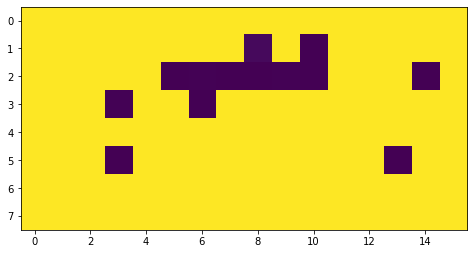

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0884, device='cuda:0')
tensor(0.1439, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [-0.0080, -0.0080, -0.0080,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0080, -0.0080, -0.0080,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0080, -0.0080, -0.0080,  ...,  0.0000,  0.0000,  0.0000]]],
       device='cuda:0')


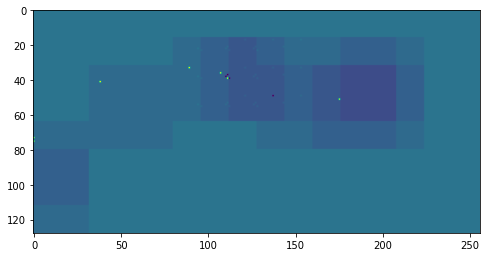

 50%|█████████████████████████████████████████                                         | 12/24 [00:10<00:10,  1.11it/s]

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0232
theta_y: 0.0013
theta_z: 0.0020
phi: 0.0049
gamma: -0.0043
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0.0079, device='cuda:0')
tensor([[[ 1.5879e-02,  1.5879e-02, -1.5879e-02,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.3818e-02,  2.3818e-02,  4.7636e-02,  4.7636e-02,  3.1758e-02,
           7.9394e-03,  7.9394e-03,  2.3818e-02, -2.3818e-02,  1.5879e-02,
           1.5879e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 3.1758e-02,  1.5879e-02, -1.8094e+01,  3.1758e-02,  4.7636e-02,
          -1.8245e+01, -1.8181e+01,  7.9394e-03, -1.8253

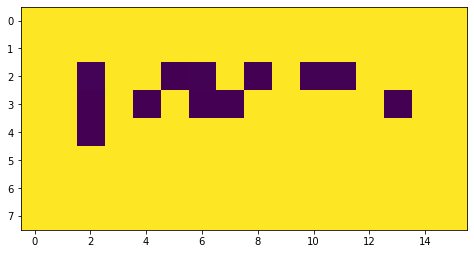

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.1463, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


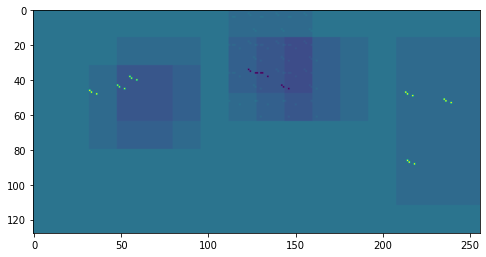

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:11<00:10,  1.09it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0236
theta_y: 0.0010
theta_z: 0.0022
phi: 0.0050
gamma: -0.0044
rho: -0.0019
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 8.2960e-03, -8.2960e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00, -1.6592e-02,
           1.6592e-02],
         [ 8.2960e-03,  8.2960e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  4.9776e-02, -9.9552e-02, -9.3132e-10,
           1.6592e-02,  1.7422e-01, -1.8683e+01,  5.8072e-02,  1.6592e-02,
           1.6592e-02],
         [ 1.0785e-01,  1.0785e-01,  8.2960e-03,  0.0000e+00,  0.0000e+00,
           4.1480e-02,  4.1480e-02,  8.2960e-03, -1.8176

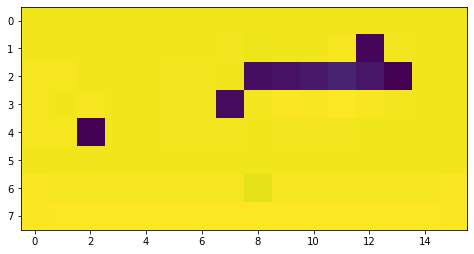

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0898, device='cuda:0')
tensor(0.1455, device='cuda:0')
tensor([[[0.1038, 0.0000, 0.0000,  ..., 0.0000, 0.1038, 0.1038],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.1038, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.1038, 0.1038, 0.1038,  ..., 0.1038, 0.0000, 0.1038]]],
       device='cuda:0')


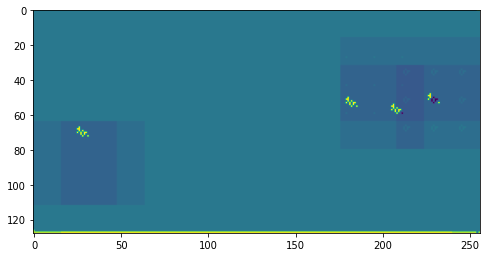

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:12<00:09,  1.08it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0272
theta_y: 0.0011
theta_z: 0.0026
phi: 0.0058
gamma: -0.0049
rho: -0.0019
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0072, device='cuda:0')
tensor(0.0072, device='cuda:0')
tensor([[[  0.4548,  -0.1083,   0.1155,   0.1155,   0.1155,   0.1155,   0.1155,
            0.1155,  -0.3465,   0.1155,   0.1155,   0.1155,   0.1155,   0.1155,
            0.1155,   0.2310],
         [  0.9313,   1.1335,   0.6931,   0.6642,   0.4693,   0.3610,   0.5703,
            0.3032,  -0.0217,   0.6786,   0.5487,   0.3465,   0.3465,   0.3465,
            0.3465,   0.2310],
         [  0.8808,   0.5631,   0.4187, -15.2692, -14.1574, -15.5002, -15.0815,
          -15.1465, -14.5833, -13.4715, -16.0633,   0.0722,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.7508, -15.4352, -15.7168, -15.5002, -15.94

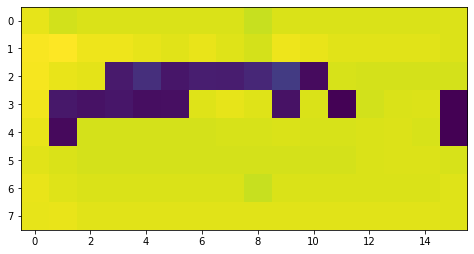

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.1525, device='cuda:0')
tensor([[[0.0894, 0.0894, 0.0894,  ..., 0.0894, 0.0894, 0.0894],
         [0.0894, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0894, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0894, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0894, 0.0000, 0.0000,  ..., 0.0000, 0.0894, 0.0894],
         [0.0894, 0.0894, 0.0894,  ..., 0.0894, 0.0894, 0.0894]]],
       device='cuda:0')


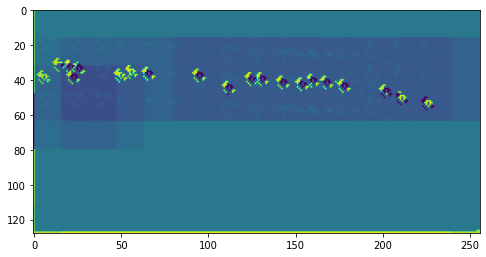

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:13<00:08,  1.07it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0301
theta_y: 0.0010
theta_z: 0.0031
phi: 0.0064
gamma: -0.0056
rho: -0.0021
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[  0.5212,  -0.1241,   0.1324,   0.1324,   0.1324,   0.1324,   0.1324,
            0.1324,  -0.3971,   0.1324,   0.1324,   0.1324,   0.1324,   0.1324,
           -0.1324,   0.5295],
         [  0.7943,   0.7032,   0.3640,   0.4385,   0.3806,   0.3806,   0.6536,
            0.7198,   0.1076,   0.6288,   0.5626,   0.3971,   0.3971,   0.3971,
            0.5295,   0.6619],
         [  0.6453,   0.4054, -16.2988, -18.6401,   0.0827,  -0.0248,   0.2565,
            0.1241, -17.2916, -17.4239, -18.5491,   0.0000,   0.0000,   0.0000,
            0.1324,   0.3971],
         [  0.6453,   0.2068,   0.3806, -18.6981, -17.98

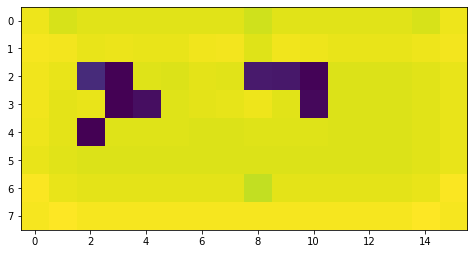

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0895, device='cuda:0')
tensor(0.1433, device='cuda:0')
tensor([[[0.0988, 0.0988, 0.0988,  ..., 0.0988, 0.0988, 0.0988],
         [0.0988, 0.0000, 0.0000,  ..., 0.0000, 0.0988, 0.0988],
         [0.0988, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0988],
         ...,
         [0.0988, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0988],
         [0.0988, 0.0988, 0.0988,  ..., 0.0988, 0.0988, 0.0988],
         [0.0988, 0.0988, 0.0988,  ..., 0.0988, 0.0988, 0.0988]]],
       device='cuda:0')


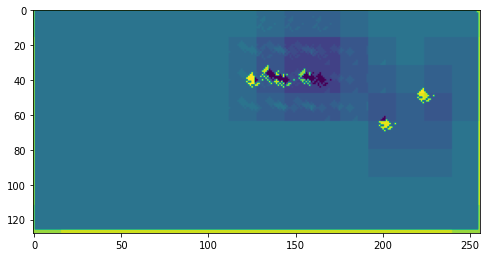

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:14<00:07,  1.07it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0359
theta_y: -0.0007
theta_z: 0.0041
phi: 0.0072
gamma: -0.0063
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0078, device='cuda:0')
tensor(0.0078, device='cuda:0')
tensor([[[  0.4916,   0.3979,   0.4057,   0.4214,   0.5306,   0.3745,   0.2965,
            0.3745,   0.3745,   0.3745,   0.3745,   0.3745,   0.3745,   0.3745,
            0.3589,   0.7335],
         [  0.6164,   0.6710,   0.6164,   0.7179,   0.9441,   0.4916,   0.6008,
            0.9832,  -0.1951,   0.6788, -14.3650,   0.4292,   0.3823,   0.6164,
            0.7101,   0.9988],
         [  0.3745,   0.3043,   0.1795, -16.6356, -15.9178, -14.9970, -17.0882,
            0.3277, -15.8398, -15.5120, -16.1597, -15.9334, -15.5901, -16.8931,
          -16.6044,   1.0612],
         [  0.3745,   0.2731,   0.2107,   0.4682,   0.5

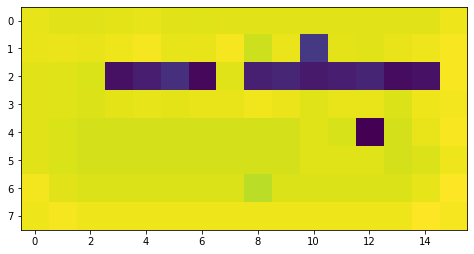

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0896, device='cuda:0')
tensor(0.1523, device='cuda:0')
tensor([[[0.0331, 0.0331, 0.0331,  ..., 0.0331, 0.0331, 0.0331],
         [0.0331, 0.0000, 0.0000,  ..., 0.0000, 0.0331, 0.0331],
         [0.0331, 0.0000, 0.0000,  ..., 0.0000, 0.0331, 0.0331],
         ...,
         [0.0993, 0.0000, 0.0000,  ..., 0.0000, 0.0993, 0.0993],
         [0.0993, 0.0993, 0.0993,  ..., 0.0993, 0.0993, 0.0993],
         [0.0993, 0.0993, 0.0993,  ..., 0.0993, 0.0993, 0.0993]]],
       device='cuda:0')


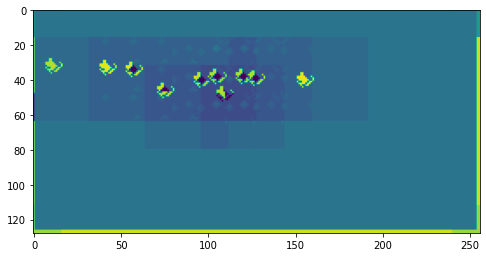

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:15<00:06,  1.07it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0394
theta_y: -0.0019
theta_z: 0.0050
phi: 0.0080
gamma: -0.0070
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0.0074, device='cuda:0')
tensor([[[ 6.9734e-01,  6.9734e-01,  7.1218e-01,  7.1218e-01,  7.1218e-01,
           7.1960e-01,  8.0120e-01,  7.9378e-01,  6.2316e-01,  7.1960e-01,
           7.1218e-01,  7.1218e-01,  7.1218e-01,  7.1218e-01,  6.8251e-01,
           9.1990e-01],
         [ 8.1604e-01,  8.1604e-01,  7.1218e-01,  7.1218e-01,  1.0609e+00,
           1.5876e+00,  1.1054e+00,  2.8932e-01, -9.8889e+00, -1.3739e+01,
           2.5223e-01,  9.7925e-01,  1.3873e+00,  9.1990e-01,  9.1990e-01,
           1.1573e+00],
         [ 5.4897e-01, -1.4837e-02,  0.0000e+00,  0.0000e+00,  3.4867e-01,
           7.4185e-01, -1.4125e+01, -1.1788e+01, -1.339

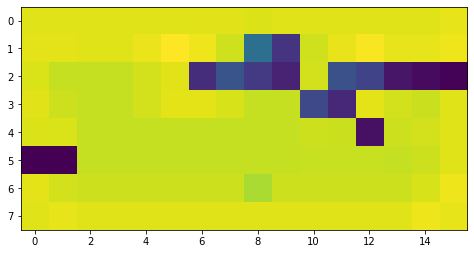

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0896, device='cuda:0')
tensor(0.1522, device='cuda:0')
tensor([[[0.0347, 0.0347, 0.0347,  ..., 0.0347, 0.0347, 0.0347],
         [0.0347, 0.0347, 0.0347,  ..., 0.0347, 0.0347, 0.0347],
         [0.0347, 0.0000, 0.0000,  ..., 0.0000, 0.0347, 0.0347],
         ...,
         [0.1041, 0.0000, 0.0000,  ..., 0.0000, 0.1041, 0.1041],
         [0.1041, 0.1041, 0.1041,  ..., 0.1041, 0.1041, 0.1041],
         [0.1041, 0.1041, 0.1041,  ..., 0.1041, 0.1041, 0.1041]]],
       device='cuda:0')


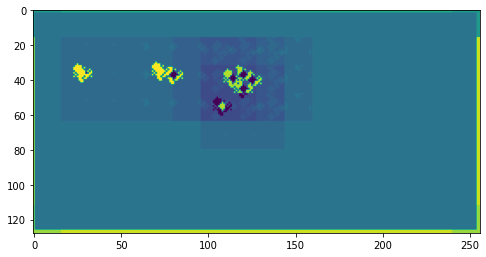

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:16<00:05,  1.07it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0410
theta_y: -0.0054
theta_z: 0.0062
phi: 0.0084
gamma: -0.0075
rho: -0.0017
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0.0079, device='cuda:0')
tensor([[[ 8.1091e+00,  8.1091e+00,  8.1091e+00,  8.1091e+00,  8.1091e+00,
           8.1091e+00,  8.1091e+00,  8.1091e+00,  4.0978e-08,  8.1091e+00,
           8.1091e+00,  8.1091e+00,  8.1091e+00,  8.1091e+00,  8.1091e+00,
           8.1091e+00],
         [ 1.2164e+01,  1.4191e+01,  1.4167e+01,  1.3827e+01,  1.3391e+01,
           1.4048e+01,  1.4476e+01,  1.3930e+01,  6.9846e+00,  1.3692e+01,
           1.3755e+01,  1.4191e+01,  1.4191e+01,  1.4191e+01,  1.4191e+01,
           1.2164e+01],
         [ 1.2164e+01,  1.4191e+01,  1.2140e+01,  9.7721e+00,  0.0000e+00,
           0.0000e+00, -5.5433e-02,  9.6691e+00,  0.000

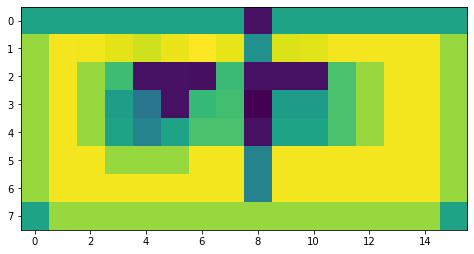

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0794, device='cuda:0')
tensor(0.1350, device='cuda:0')
tensor([[[0.0281, 0.0281, 0.0281,  ..., 0.0281, 0.0281, 0.0281],
         [0.0281, 0.0281, 0.0281,  ..., 0.0281, 0.0281, 0.0281],
         [0.0281, 0.0281, 0.0281,  ..., 0.0281, 0.0281, 0.0281],
         ...,
         [0.0844, 0.0844, 0.0844,  ..., 0.0844, 0.0844, 0.0844],
         [0.0844, 0.0844, 0.0844,  ..., 0.0844, 0.0844, 0.0844],
         [0.0844, 0.0844, 0.0844,  ..., 0.0844, 0.0844, 0.0844]]],
       device='cuda:0')


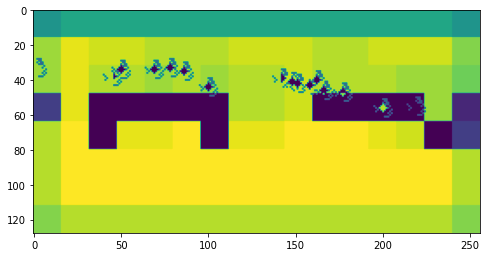

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:17<00:04,  1.08it/s]

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')
theta_x: 0.0437
theta_y: -0.0088
theta_z: 0.0070
phi: 0.0088
gamma: -0.0081
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -19.1435,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000, -19.1435, -19.1435, -19.1435, -19.1435, -19.1435,
            0.0000, -19.1435,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,

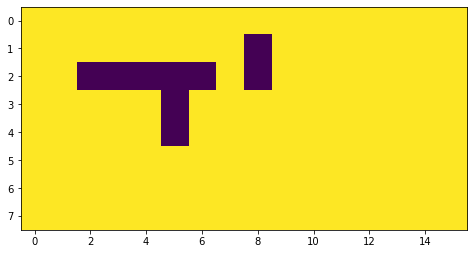

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0477, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


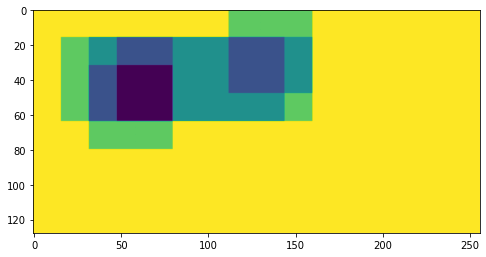

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:18<00:03,  1.06it/s]

tensor(-0.2498, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0437
theta_y: -0.0088
theta_z: 0.0070
phi: 0.0088
gamma: -0.0081
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0073, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -16.7504, -16.7504, -16.7504,
          -16.7504, -16.7504, -16.7504, -16.7504, -16.7504,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -16.7504, -16.7504, -16

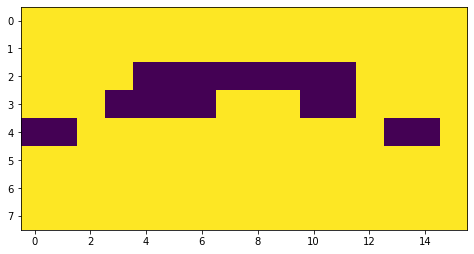

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0444, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


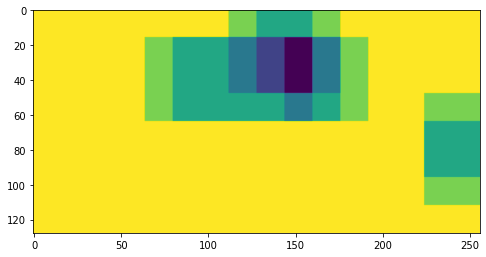

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:19<00:02,  1.06it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0437
theta_y: -0.0088
theta_z: 0.0070
phi: 0.0088
gamma: -0.0081
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0078, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -18.0370,   0.0000, -18.0370,   0.0000, -18.0370,   0.0000,
          -18.0370, -18.0370, -18.0370, -18.0370,   0.0000, -18.0370,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -18.0370, -18.0370,   0.0000,   0.0000,   0

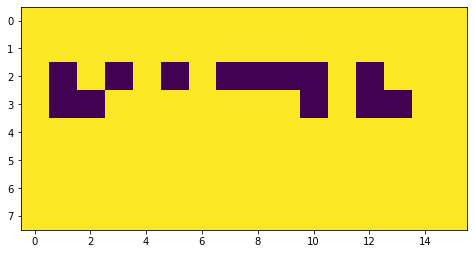

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0491, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


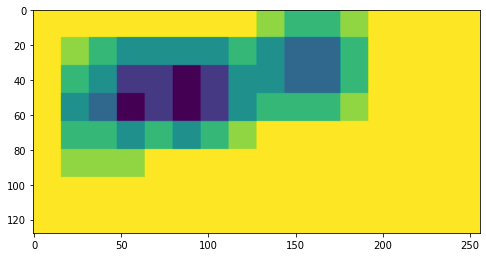

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:20<00:02,  1.01s/it]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0437
theta_y: -0.0088
theta_z: 0.0070
phi: 0.0088
gamma: -0.0081
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000, -19.1393, -19.1393,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -19.1393, -19.1393,   0.0000,   0.0000,
          -19.1393, -19.1393, -19.1393, -19.1393,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -19.1393,   0

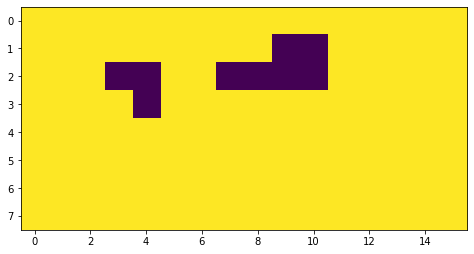

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0422, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


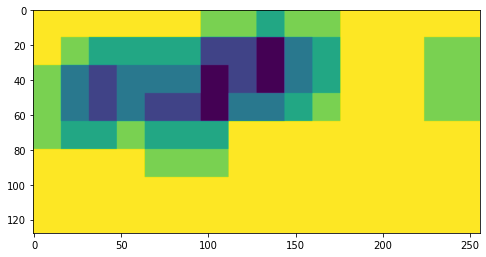

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:21<00:00,  1.02it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0437
theta_y: -0.0088
theta_z: 0.0070
phi: 0.0088
gamma: -0.0081
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0078, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -17.9489, -17.9489, -17.9489,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -17.9489,   0.0000,
          -17.9489, -17.9489, -17.9489,   0.0000, -17.9489, -17.9489, -17.9489,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -17

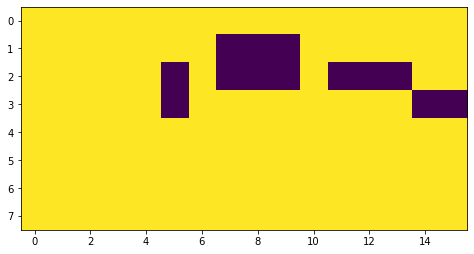

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0467, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


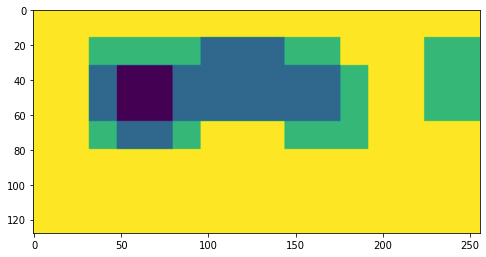

  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
theta_x: 0.0437
theta_y: -0.0088
theta_z: 0.0070
phi: 0.0088
gamma: -0.0081
rho: -0.0013
Train Epoch: (4, 1) 	LR: 0.001000	Loss: 21.494565


In [ ]:
import time
%time


n_epochs_list = [4]
lr_list = [1e-3]
batch_size = 16
n = 4
optimizer = None
model = None


train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=train_sampler)
dev_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=valid_sampler)

fileName = None
dev_history = pd.DataFrame(index=pd.MultiIndex.from_tuples((), names=['epoch', 'lr']), columns=['theta_x', 'theta_y', 'theta_z', 'dev_loss'])

torch.cuda.empty_cache()
gc.collect()

for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        n_epochs = n_epochs_list[i_epoch]
        lr = lr_list[i_lr]
        train_history = pd.DataFrame(index=pd.MultiIndex.from_tuples((), names=['zoom', 'epoch', 'batch_id']), columns=['theta_x', 'theta_y', 'theta_z', 'loss'])

        model = create_model(CAMERA, n)
        if fileName is not None:
            state_dict = torch.load(fileName, map_location='cpu')
            model.load_state_dict(state_dict, strict=False)
            del state_dict
            print("Loaded!!")
        model = model.to(device)

        torch.cuda.empty_cache()

        gc.collect()
        optimizer = optim.SGD(list(model.parameters()), lr=lr)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=n_epochs, gamma=1.25)

        torch.cuda.empty_cache()
        gc.collect()

        for i in range(n+1):
            for epoch in range(n_epochs):
                zoom = n-i
                torch.cuda.empty_cache()
                gc.collect()

                loader = train_loader
                train_loop_fn(loader, zoom, epoch, train_history)
                
                # scheduler.step()

        loader = dev_loader
        start = time.time()*1000.0
        evaluate_model(loader, (n_epochs, lr), dev_history)
        t_interval = time.time()*1000.0 - start
        print("Speed: {} ms/sample".format(t_interval/(len(dev_loader)*batch_size)))

        gc.collect()
        optimizer = None
        gc.collect()

        train_history.to_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        torch.save(model.state_dict(), "./model_{}_{}.pth".format(i_epoch, i_lr))
dev_history.to_csv('dev_history.csv')

# Result Assessment

**Quantification**

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        train_history[['loss']].plot();
        train_history[['theta_x', 'theta_y', 'theta_z']].plot();

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        train_history[['loss']].plot();
        train_history[['phi', 'gamma', 'rho']].plot();

In [ ]:
dev_history

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        ax = train_history[['theta_x', 'theta_y', 'theta_z']].plot()
        fig = ax.get_figure()
        fig.savefig('./position.png')

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        ax = train_history[['phi', 'gamma', 'rho']].plot()
        fig = ax.get_figure()
        fig.savefig('./orientation.png')

**Assessing Camera Calibration via Output-Target Image Comparison**

In [ ]:
with torch.no_grad():
    for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
        r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

        r, p, y, r_mask, weights = model(input_2Dr_batch, r_mask_batch)
        
        plt.figure(figsize=(8,8))
        plt.imshow((r_mask_batch[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()
        
        plt.figure(figsize=(8,8))
        plt.imshow((target_2Dr_batch[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()
        
        print(weights.size())
        
        weights = weights[:,-1:,:,:]
        print("out_batch")
        print(weights.min())
        print(weights.max())
        plt.figure(figsize=(8,8))
        plt.imshow(((weights>specials.OFF_THRESH)[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()
        break

# Convert tensors to numpy arrays (make sure they are on CPU)
weights_np = (weights[:,-1,:,:]>specials.OFF_THRESH).float().cpu().numpy()
mask_np = (r_mask_batch[:,0,:,:]).cpu().numpy()
target_np = (target_2Dr_batch[:,0,:,:]).cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(16):
    ax = axes[i]
    ax.imshow(weights_np[i], cmap='gray', interpolation='nearest', vmin=0, vmax=1)

    out_points = np.argwhere(weights_np[i] > 0)
    target_points = np.argwhere(target_np[i] > 0)

    if target_points.size > 0:
        ax.scatter(target_points[:, 1], target_points[:, 0], facecolors='none',
                   edgecolors='red', s=10, label='Output')

    if out_points.size > 0:
        ax.scatter(out_points[:, 1], out_points[:, 0], marker='x',
                   color='blue', s=10, label='Target')

    ax.set_title(f"Image {i+1}", fontsize=10)
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

*Before calibration*

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(16):
    ax = axes[i]
    ax.imshow(weights_np[i], cmap='gray', interpolation='nearest', vmin=0, vmax=1)

    mask_points = np.argwhere(mask_np[i] == 1)
    target_points = np.argwhere(target_np[i] == 1)

    if mask_points.size > 0:
        ax.scatter(mask_points[:, 1], mask_points[:, 0], facecolors='none',
                   edgecolors='red', s=10, label='Mask')

    if target_points.size > 0:
        ax.scatter(target_points[:, 1], target_points[:, 0], marker='x',
                   color='blue', s=10, label='Target')

    ax.set_title(f"Image {i+1}", fontsize=10)
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()